In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpyro import infer, distributions as dist
import numpyro
import jax
import jax.numpy as jnp

In [5]:
dt = 0.1
Tobs = 100
times = np.arange(Tobs / dt) * dt

source_frequency = 2.223 # Hz
source_phase = 0
source_amplitude = 5.111

noise_sigma = 10.11

signal = source_amplitude * np.cos(2 * np.pi * source_frequency * times + source_phase)
noise = noise_sigma * np.random.randn(times.size)

fake_data = signal + noise

# Which templates in the template bank light up?

Let's start with the simplest thing possible:

$$ y_i = F_{ij} (a_j \circ z_j) + \eta_i$$

where $a$ are a set of amplitudes, and $z$ are a set of discrete indicator variables.

$a\circ z$ just means the element-wise product of these vectors.

$F$ is a Fourier matrix with sines and cosines, just like when we do PTA analyses.

We assume that the noise $\eta_i$ is Gaussian, $$\eta_i \sim N(0, \sigma),$$ and we assume for now we know $\sigma$.

Obviously for signals that fall not in the center of a bin, we will get multiple bins lighting up, 
this means there would have to be some sort of post-processing after the fact to sort out the actual frequency of the signal. 

In [6]:
# Here is a useful template bank...the frequencies at which we'd have an FFT.
# So this is like our "Bayesian Fourier Transform" we use in PTAs.
freqs = np.fft.rfftfreq(times.size, d=dt)
my_array = np.concat([[np.sin(2 * np.pi * f * times), np.cos(2 * np.pi * f * times)] for f in freqs[1:]]).T
print(my_array.shape)

(1000, 1000)


In [7]:
def model():
    theta = numpyro.sample('theta', dist.Uniform(0, 1))
    zs = numpyro.sample("zs", dist.Bernoulli(theta * np.ones(times.size)))
    amplitudes = numpyro.sample("amplitudes", dist.Uniform(0, 20).expand([times.size]))
    model = my_array @ (zs * amplitudes)
    numpyro.sample("loglike", dist.Normal(model, noise_sigma), obs=fake_data)

In [8]:
# kernel = 
kernel = infer.DiscreteHMCGibbs(infer.NUTS(model), modified=True) # gibbs sample the indicators
mcmc = infer.MCMC(kernel, num_samples=500, num_warmup=200)

In [9]:
mcmc.run(jax.random.key(0))

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 700/700 [00:22<00:00, 30.98it/s, 31 steps of size 1.94e-01. acc. prob=0.89]


In [10]:
samples = mcmc.get_samples()

In [11]:
# mcmc.print_summary()

In [12]:
freq_arr = np.repeat(freqs, 2)

In [13]:
# I find that, because
# the source doesn't fall at one of the
# template frequencies, I need two frequencies
# at different ampltitudes to generate it. Makes sense.
# But means there would need to be some sort of post processing. 
mean_zs = np.mean(samples['zs'], axis=0)
mean_amps = np.mean(samples['amplitudes'], axis=0)

print(freq_arr[np.where(mean_zs > 0.1)])

[2.21]


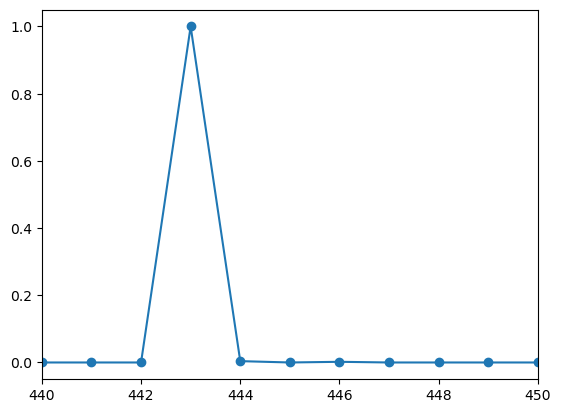

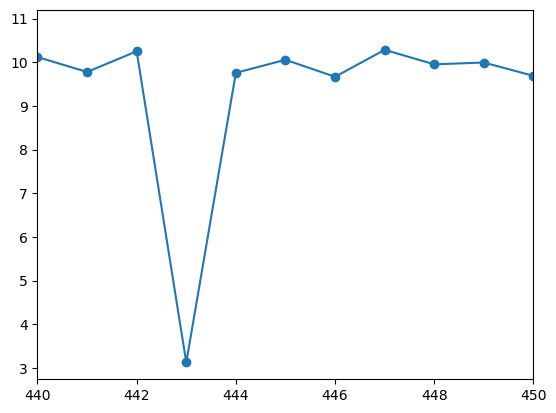

In [14]:

plt.plot(mean_zs, '-o')
plt.xlim(440, 450)
plt.show()

plt.plot(mean_amps, '-o')
plt.xlim(440, 450)
plt.show()

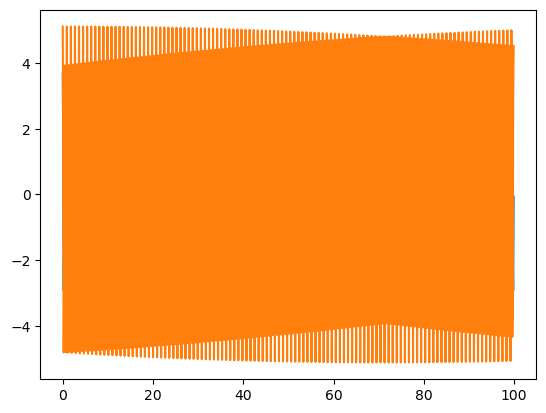

In [15]:
plt.plot(times, my_array @ (mean_zs * mean_amps))
plt.plot(times, signal)
# plt.xlim(20, 40)
plt.show()

In [16]:
mean_amps[np.where(mean_zs > 0.1)]

Array([3.1249294], dtype=float32)

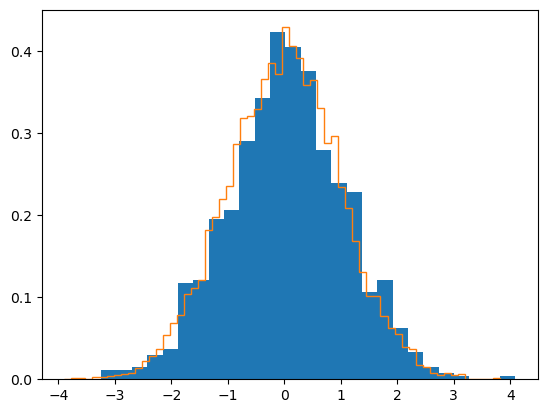

In [17]:
plt.hist((fake_data - (my_array @ (samples['zs'][123, :] * samples['amplitudes'][123, :]))) / noise_sigma, density=True, bins='auto')
plt.hist(np.random.randn(10000), density=True, histtype='step', bins='auto')
plt.show()

In [18]:
freqs[-1]

np.float64(5.0)

# 3 sources with variable frequencies?

Now let's got he complete opposite direction. Let's allow there to be 3 signals, labeled with $j$ still:

$$ y_i = \sum_{j=1}^{3} a_j z_j \sin(2\pi f_j t_i) + b_j z'_j \cos(2\pi f_j t_i),$$

where $p(f) = U(0, 5)$, $p(z=1) = \theta$, $p(\theta)=U(0, 1)$, $p(a)=U(0, 20)$. 

For now we've given separate indicators for sines and cosines, althought that may not be the best way to do it.

Below, we so the search for three sources, but there's still only one injected. We will still have the label-switching problem here, of course. 

In [19]:
def model_n_sources(nsources_available):
    theta = numpyro.sample('theta', dist.Uniform(0, 1))
    zs = numpyro.sample("zs", dist.Bernoulli(theta * np.ones(2 * nsources_available)))
    amplitudes = numpyro.sample("amplitudes", dist.Uniform(0, 20).expand([2 * nsources_available]))
    frequencies = numpyro.sample('freqs', dist.Uniform(0, 5).expand([nsources_available]))
    model = jnp.sum(jnp.concat(jnp.array([[amplitudes[2*i] * zs[2*i] * jnp.sin(2 * jnp.pi * frequencies[i] * times), 
                                           amplitudes[2*i+1] * zs[2*i+1] * jnp.cos(2 * jnp.pi * f * times)] for i, f in enumerate(frequencies)])).T, axis=1)
    numpyro.sample("loglike", dist.Normal(model, noise_sigma), obs=fake_data)

In [20]:
# kernel = 
kernel = infer.DiscreteHMCGibbs(infer.NUTS(model_n_sources, max_tree_depth=8), modified=True) # gibbs sample the indicators
mcmc = infer.MCMC(kernel, num_samples=5000, num_warmup=5000)

In [21]:
mcmc.run(jax.random.key(0), 3)

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:41<00:00, 61.80it/s, 63 steps of size 7.23e-02. acc. prob=0.87]


In [22]:
mcmc.print_summary()


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
amplitudes[0]      9.72      5.89      9.76      0.00     17.79   1225.79      1.00
amplitudes[1]      9.48      5.91      9.29      0.12     17.93   1132.05      1.00
amplitudes[2]      9.91      5.78      9.94      0.07     17.88   2517.83      1.00
amplitudes[3]      9.89      5.84      9.86      0.10     18.10   1835.04      1.00
amplitudes[4]      9.72      5.85      9.58      0.01     17.98   1890.93      1.00
amplitudes[5]      5.12      0.46      5.12      4.41      5.93   3039.06      1.00
     freqs[0]      2.52      1.45      2.51      0.45      4.87   1628.01      1.00
     freqs[1]      2.51      1.50      2.50      0.23      4.76    974.42      1.00
     freqs[2]      2.22      0.00      2.22      2.22      2.22   2112.55      1.00
        theta      0.26      0.15      0.25      0.03      0.47   1820.28      1.00
        zs[0]      0.03      0.18      0.00      0.00      0.00    468.46  

In [23]:
samples = mcmc.get_samples()

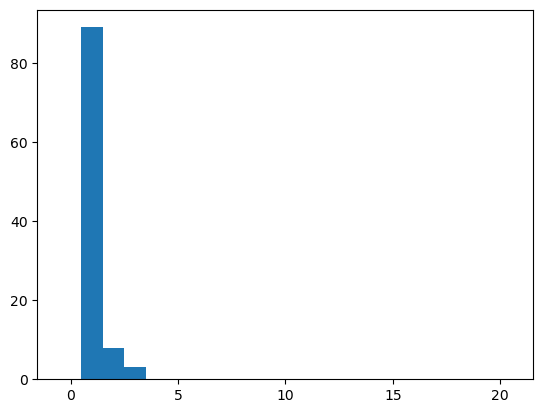

In [24]:
plt.hist(np.sum(samples['zs'], axis=1)[-100:], bins=np.linspace(-0.5, 20.5, num=22))
plt.show()

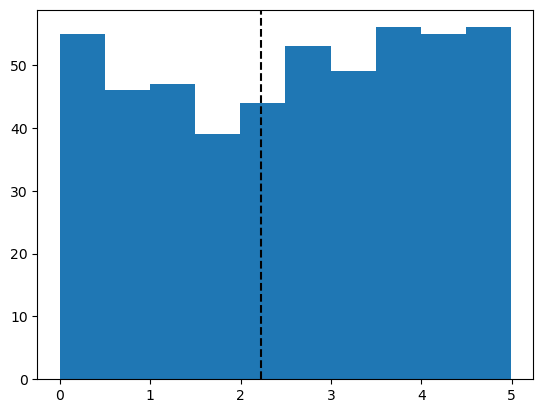

In [25]:
plt.hist(samples['freqs'][::10, 1], bins='auto')
ax = plt.gca()
ax.axvline(source_frequency, c='k', ls='--')
plt.show()

# Ordering the frequencies

What if we impose some a-priori ordering on the frequencies?

\begin{align}
p(f_0) &= U(0, 5)\\
p(f_i) &= U(f_{i-1}, 5) \textrm{ for $i\geq 1$}
\end{align}

Let's just apply this in a loop

In [217]:
def model_n_sources_ordering(nsources_available, data):
    theta = numpyro.sample('theta', dist.Uniform(0, 1))
    zs = numpyro.sample("zs", dist.Bernoulli(theta * np.ones(2 * nsources_available)))
    amplitudes = numpyro.sample("amplitudes", dist.Uniform(0, 20).expand([2 * nsources_available]))
    frequencies = [numpyro.sample(f'f0', dist.Uniform(0, 5))]
    for ii in range(1,nsources_available):
        frequencies.append(numpyro.sample(f'f{ii}', dist.Uniform(frequencies[-1], 5)))
    # frequencies = numpyro.sample('freqs', dist.Uniform(0, 5).expand([nsources_available]))
    model = jnp.sum(jnp.concat(jnp.array([[amplitudes[2*i] * zs[2*i] * jnp.sin(2 * jnp.pi * frequencies[i] * times), 
                                           amplitudes[2*i+1] * zs[2*i+1] * jnp.cos(2 * jnp.pi * f * times)] for i, f in enumerate(frequencies)])).T, axis=1)
    numpyro.sample("loglike", dist.Normal(model, noise_sigma), obs=data)

In [218]:
# kernel = 
kernel = infer.DiscreteHMCGibbs(infer.NUTS(model_n_sources_ordering, max_tree_depth=8), modified=True) # gibbs sample the indicators
mcmc = infer.MCMC(kernel, num_samples=1000, num_warmup=3000)

In [219]:
mcmc.run(jax.random.key(0), 3, fake_data)

sample: 100%|███████████████████████████████████████████████████████████| 4000/4000 [01:56<00:00, 34.41it/s, 3 steps of size 7.95e-02. acc. prob=0.90]


In [220]:
samples = mcmc.get_samples()

In [221]:
mcmc.print_summary()


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
amplitudes[0]      9.96      5.88     10.06      0.05     18.09    502.22      1.00
amplitudes[1]      5.37      0.42      5.35      4.71      6.04    935.70      1.00
amplitudes[2]     10.16      5.48     10.24      2.01     19.15    739.37      1.01
amplitudes[3]     10.10      5.86     10.07      0.34     18.33    614.26      1.00
amplitudes[4]      9.93      5.92      9.66      1.73     19.94    587.90      1.00
amplitudes[5]      9.72      5.93      9.82      0.22     18.02    976.22      1.00
           f0      2.22      0.00      2.22      2.22      2.22    530.07      1.00
           f1      3.59      0.79      3.60      2.33      4.79   1184.49      1.00
           f2      4.30      0.62      4.48      3.36      5.00    752.18      1.00
        theta      0.26      0.14      0.24      0.03      0.48    485.11      1.00
        zs[0]      0.02      0.15      0.00      0.00      0.00    408.57  

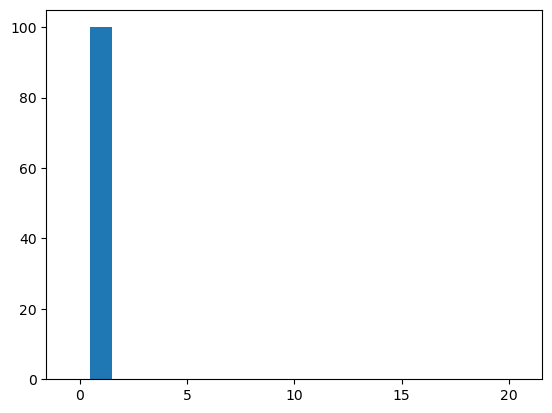

In [208]:
plt.hist(np.sum(samples['zs'], axis=1)[-100:], bins=np.linspace(-0.5, 20.5, num=22))
plt.show()

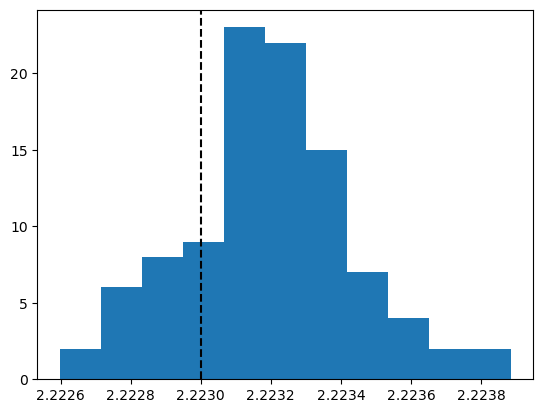

In [210]:
plt.hist(samples['freqs'][::10, 2], bins='auto')
ax = plt.gca()
ax.axvline(source_frequency, c='k', ls='--')
plt.show()

# 2 sources, ordering

Now let's inject two sources. We'll allow for 10 possible sources.

ChatGPT suggested a different, vectorized form of the same prior using a "stick-breaking" algorithm. That is:

define $f_0 \sim p(f_0)$ and then:

$f_1 = f_0 + (b - f_0) \xi_1$ 

where $\xi_i \sim U(0, 1)$. This makes sense -- $(b - f_0)$ is the width we have left in the "stick" and $f_0$ is where it starts from. 
We then define this iteratively. 

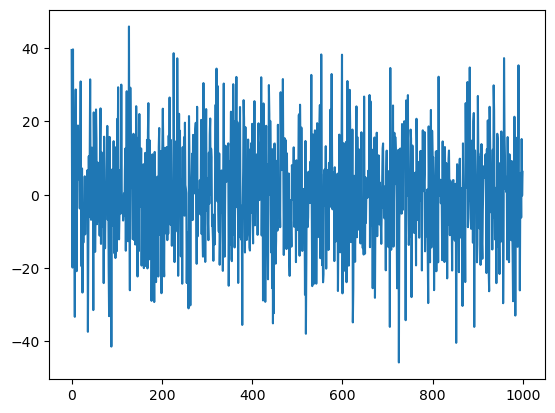

In [27]:
dt = 0.1
Tobs = 100
times = np.arange(Tobs / dt) * dt

source_frequency = 2.223 # Hz
source_phase = 0
source_amplitude = 5.111

source_frequency2 = 3.456 # Hz
source_phase2 = 0 # 1.123
source_amplitude2 = 7.111

noise_sigma = 13.11 # smaller noise?

signal1 = source_amplitude * np.cos(2 * np.pi * source_frequency * times + source_phase)
signal2 = source_amplitude2 * np.cos(2 * np.pi * source_frequency2 * times + source_phase2)
noise = noise_sigma * np.random.randn(times.size)

fake_data_multisource = signal1 + noise + signal2
plt.plot(fake_data_multisource)
# plt.plot(signal1)
# plt.plot(signal2)
plt.show()

In [28]:

# chatgpt suggestion for faster model calculation and imposing frequency ordering.
# a cool idea, but i have no idea if it is correct...
def model_n_sources_two_z(nsources, data):
    # --- hyperparameters ---
    theta = numpyro.sample("theta", dist.Uniform(0., 1.))
    sigma = numpyro.sample("sigma", dist.HalfCauchy(1.))

    # --- 2 × nsources indicators ---
    zs = numpyro.sample("zs", dist.Bernoulli(theta).expand([2, nsources]))  # [2, nsources]

    # --- amplitudes for each sine/cosine ---
    amplitudes = numpyro.sample("amplitudes", dist.Uniform(0., 20.).expand([2, nsources]))  # [2, nsources]

    # --- ordered frequencies: exact hierarchical prior ---
    # This is a chat gpt suggestion. It's cool! And it seems to work. 
    # It's known as a "stick-breaking" algorithm. 
    u0 = numpyro.sample("u0", dist.Uniform(0., 1.))
    f0 = 3.0 * u0
    if nsources > 1:
        v = numpyro.sample("v", dist.Uniform(0., 1.).expand([nsources - 1]))
        cumprod = jnp.cumprod(1.0 - v)
        freqs_tail = 5.0 - (5.0 - f0) * cumprod
        freqs = jnp.concatenate([jnp.array([f0]), freqs_tail])
    else:
        freqs = jnp.array([f0])
    numpyro.deterministic('freqs', freqs)
    # --- waveform construction ---
    phases = 2.0 * jnp.pi * freqs[:, None] * times[None, :]  # [nsources, ntimes]
    sines = jnp.sin(phases)  # [nsources, ntimes]
    coses = jnp.cos(phases)  # [nsources, ntimes]

    # combine both harmonics; careful broadcasting of amplitudes & zs:
    # amplitudes[0, :] * zs[0, :] * sines -> [nsources, ntimes]
    # amplitudes[1, :] * zs[1, :] * coses -> [nsources, ntimes]
    model = (
        jnp.sum(amplitudes[0, :, None] * zs[0, :, None] * sines, axis=0)
        + jnp.sum(amplitudes[1, :, None] * zs[1, :, None] * coses, axis=0)
    )  # [ntimes]

    numpyro.sample("obs", dist.Normal(model, sigma), obs=data)

In [29]:
# kernel = 
kernel = infer.DiscreteHMCGibbs(infer.NUTS(model_n_sources_two_z, max_tree_depth=8), modified=False) # gibbs sample the indicators
mcmc = infer.MCMC(kernel, num_samples=5000, num_warmup=5000)

In [30]:
mcmc.run(jax.random.key(123), 5, fake_data_multisource)

sample: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:04<00:00, 54.32it/s, 255 steps of size 9.97e-04. acc. prob=0.95]


In [31]:
mcmc.print_summary()


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
amplitudes[0,0]     10.76      5.28     11.15      2.29     19.07     75.65      1.02
amplitudes[0,1]     11.23      6.06     12.73      1.66     19.19     11.37      1.15
amplitudes[0,2]      6.37      4.58      5.45      0.45     13.21     12.87      1.15
amplitudes[0,3]     12.16      4.31     12.98      4.16     18.67      9.42      1.12
amplitudes[0,4]      8.40      5.56      7.73      0.49     17.05     16.95      1.00
amplitudes[1,0]      5.58      0.51      5.59      4.67      6.35     20.65      1.04
amplitudes[1,1]      6.74      0.58      6.74      5.80      7.70    321.72      1.00
amplitudes[1,2]     10.33      4.68     10.06      3.68     18.13     23.40      1.05
amplitudes[1,3]      4.64      3.90      3.84      0.14     10.09     13.72      1.01
amplitudes[1,4]     12.22      5.17     12.96      4.24     19.90     16.14      1.07
          sigma     13.20      0.28     13.22     12.

In [32]:
samples = mcmc.get_samples()

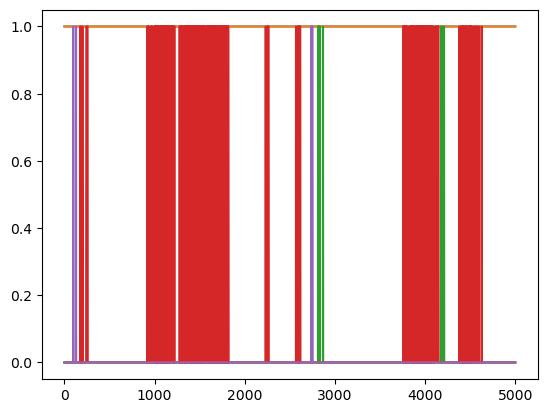

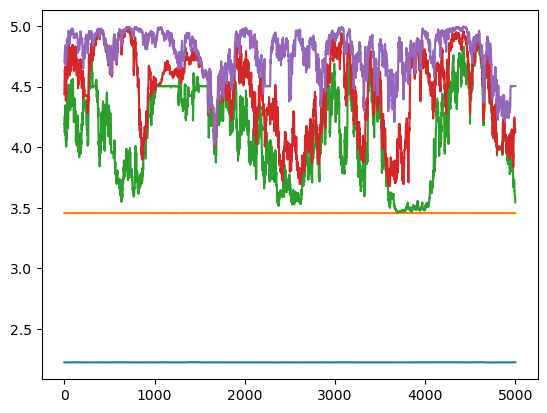

In [33]:
plt.plot(samples['zs'][:, 2])
plt.show()
plt.plot(samples['freqs'])

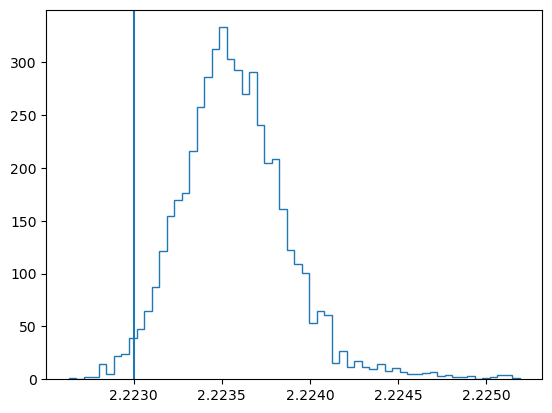

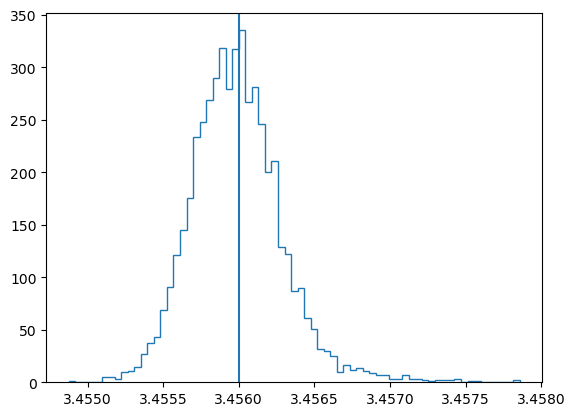

In [38]:
plt.hist(samples['freqs'][:, 0], bins='auto', histtype='step')
plt.gca().axvline(source_frequency)
plt.show()
plt.hist(samples['freqs'][:, 1], bins='auto', histtype='step')
plt.gca().axvline(source_frequency2)
plt.show()

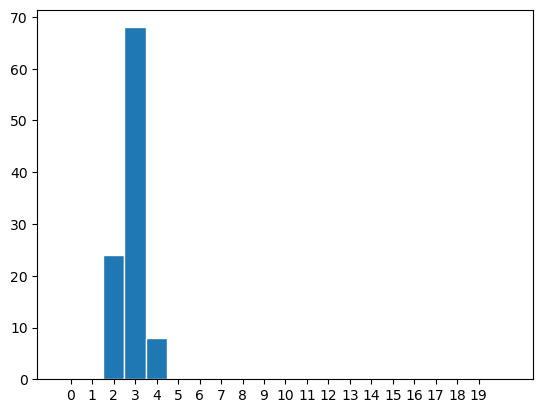

In [50]:
plt.hist(np.sum(samples['zs'], axis=(1, 2))[-100:], bins=np.linspace(-0.5, 20.5, num=22), edgecolor='w')
plt.xticks(np.arange(0, 20))
plt.show()

In [39]:
samples['zs'].shape

(5000, 2, 5)

In [42]:
np.sum(samples['zs'], axis=0).shape

(2, 5)

# Let's now return to the GP-based method, but with a variable design matrix

This way, we can put a population prior on the amplitude of the sources that are turned on, and sample that prior.
For now, we just have a single, unit-variance Gaussian with zero mean. 

We use a decentering transformation, because we can invert the problem and get an estimate of the mean for the amplitudes using the typical
method. The decentering does not really seem to be helping at the moment. 

We also restrict the range each potential source can take into 50% overlapping bins, but preserve ordering. That seems to do quite well. We may need to figure out something better in the future, though. 

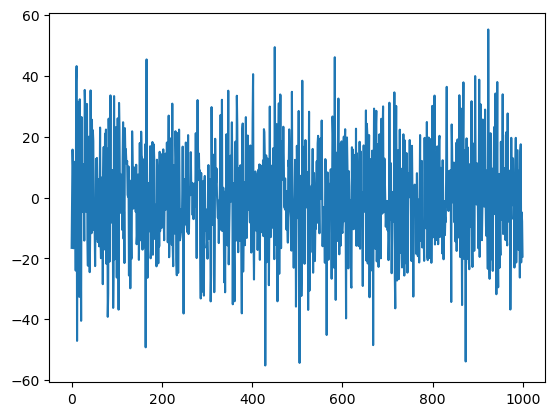

In [557]:
dt = 0.1
Tobs = 100
times = np.arange(Tobs / dt) * dt

# source_frequency = 2.223 # Hz
# source_phase = 0
# source_amplitude = 5.111

# source_frequency2 = 3.456 # Hz
# source_phase2 = 0 # 1.123
# source_amplitude2 = 10.111

# noise_sigma = 13.11 # smaller noise?

# signal1 = source_amplitude * np.cos(2 * np.pi * source_frequency * times + source_phase)
# signal2 = source_amplitude2 * np.cos(2 * np.pi * source_frequency2 * times + source_phase2)

def generate_random_sinusoids(times, n_sinusoids=5, 
                              amp_range=(5, 10), freq_range=(2, 4), phase_range=(0, 2*np.pi)):
    """
    Generate a sum of arbitrary sinusoids.

    Parameters
    ----------
    times : array-like
        Array of time points.
    n_sinusoids : int
        Number of sinusoids to sum.
    amp_range : tuple
        (min_amp, max_amp)
    freq_range : tuple
        (min_freq, max_freq)
    phase_range : tuple
        (min_phase, max_phase)

    Returns
    -------
    signal : np.ndarray
        The sum of sinusoids evaluated at `times`.
    params : dict
        Dictionary with keys 'amplitudes', 'frequencies', 'phases'.
    """
    amplitudes = np.random.uniform(amp_range[0], amp_range[1], n_sinusoids)
    frequencies = np.random.uniform(freq_range[0], freq_range[1], n_sinusoids)
    phases = np.random.uniform(phase_range[0], phase_range[1], n_sinusoids)
    
    signal = np.zeros_like(times, dtype=float)
    for A, f, phi in zip(amplitudes, frequencies, phases):
        signal += A * np.sin(2 * np.pi * f * times + phi)
    
    params = {'amplitudes': amplitudes, 'frequencies': frequencies, 'phases': phases}
    
    return signal, params
## INJECT 2
signal, inj_params = generate_random_sinusoids(times, 3)
noise = noise_sigma * np.random.randn(times.size)

fake_data_multisource = noise + signal
plt.plot(fake_data_multisource)
# plt.plot(signal1)
# plt.plot(signal2)
plt.show()

In [602]:

import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
# from numpyro.distributions.relaxations import RelaxedBernoulli
from jax.scipy.linalg import cho_factor, cho_solve, solve_triangular

# helper: build design matrix X with interleaved [sin_1, cos_1, sin_2, cos_2, ...]
def build_design_matrix_vec(freqs, times):
    """
    freqs: jnp.array shape (nsources,)
    times: jnp.array shape (N,)
    returns X: jnp.array shape (N, 2*nsources)
    """
    phases = 2.0 * jnp.pi * (freqs[:, None] * times[None, :])  # [nsources, N]
    sines = jnp.sin(phases)   # [nsources, N]
    coses = jnp.cos(phases)
    # stack as [N, nsources, 2] then reshape -> [N, 2*nsources]
    stacked = jnp.stack([sines.T, coses.T], axis=-1)  # [N, nsources, 2]
    X = jnp.reshape(stacked, (times.shape[0], 2 * freqs.shape[0]))  # [N, M]
    return X

def make_50pct_overlap_bins(N=30, f_min=0.0, f_max=5.0):
    """
    Make 50% overlapping bins (we can do even more overlap if we want)
    so that we don't get everythign clustered in one place because 
    one frequency wanders near the top and squeezes out all the rest. 
    """
    centers = np.linspace(f_min, f_max, N)
    df = centers[1] - centers[0]
    L = np.maximum(centers - df, f_min)
    U = np.minimum(centers + df, f_max)
    return L, U

def ordered_uniform_bins(L, U):
    """
    returns f[0:N]
    f_k ~ Uniform( max(f_{k-1}, L[k]), U[k] )
    """
    N = L.shape[0]
    f = [None] * N

    # step 0
    ell0 = jnp.max(jnp.array([0.0, L[0]]))
    f0 = numpyro.sample(f"f_0", dist.Uniform(low=ell0, high=U[0]))
    f[0] = f0

    # steps 1..N-1
    for k in range(1, N):
        # note: this is dynamic in the sense it depends on previous f
        low_k = jnp.maximum(f[k-1], L[k])
        # we MUST require low < U[k]. if not, numpyro will crash.
        numpyro.deterministic(f"low_{k}", low_k)
        f[k] = numpyro.sample(f"f_{k}", dist.Uniform(low=low_k, high=U[k]))

    return jnp.stack(f)

L_np, U_np = make_50pct_overlap_bins(30, 0.0, 5.0)


# original
def stick_breaking_frequencies(nsources, fmin=2.0, fmax=4.0):
    """
    Sample frequencies using stick-breaking:
    f0 ~ Uniform(fmin, 3)
    fi ~ Uniform(f_{i-1}, fmax)
    """
    v0 = numpyro.sample("v0", dist.Uniform(0,1))
    f0 = fmin + (fmax - fmin)/nsources * v0 # restrict first one to be quite low
    frequencies = [f0]
    prod = 1.0
    v = numpyro.sample("v", dist.Uniform(0., 1.).expand([nsources - 1]))
    cumprod = jnp.cumprod(1.0 - v)
    freqs_tail = fmax - (fmax - f0) * cumprod
    frequencies = jnp.concatenate([jnp.array([f0]), freqs_tail])
    return jnp.array(frequencies)

def posterior_informed_spike_slab_full_model(data, times, nsources):
    N = len(times)

    # Sample frequencies using stick-breaking
    # frequencies = stick_breaking_frequencies(nsources)
    frequencies = ordered_uniform_bins(L_np, U_np)
    numpyro.deterministic('freqs', frequencies)
    
    # Build design matrix: 2 columns per source (sin, cos)
    # X = jnp.column_stack([jnp.sin(2 * jnp.pi * f * times) for f in frequencies] +
                         # [jnp.cos(2 * jnp.pi * f * times) for f in frequencies])
    X = build_design_matrix_vec(frequencies, times)
    M = X.shape[1]  # 2 * nsources
    
    # Spike-and-slab fraction (fixed for stability)
    theta = numpyro.sample("theta", dist.Uniform(0, 1))

    # I think above we had been allowing sine or cosine for one frequency to turn off
    # that's a bit weird...like a spike-and-slab on the phase being zero or pi?
    # No...let's always sample the phase in addition to the amplitude. 
    # so we always sample the coefficient for both sine and cosine. 
    zs = jnp.repeat(numpyro.sample("zs", dist.Bernoulli(probs=theta).expand([nsources])), 2)
    
    # Spike-and-slab scale
    sigma_beta = numpyro.sample("sigma_beta", dist.Uniform(0, 100))
    
    # Observation noise
    sigma = numpyro.sample("sigma", dist.HalfCauchy(1.0))
    
    # Prior diagonal (with small floor for numerical stability)
    D = (sigma_beta * zs)**2 + 1e-2
    
    # Conditional posterior for beta given z, sigma, and X
    
    XtX = X.T @ X
    B = jnp.diag(D**-1) + XtX / sigma**2
    cho_B = cho_factor(B)

    # just in like in PTA land
    # mu_beta = (XtNmX + D^-1)^{-1} X Nm y
    # sigma_beta = (XtNmX + D^-1)
    #
    # since we know this, we sample an auxiliary variable
    # and transform to be around this region, with roughly this scale.
    # this gets rid of the funnel, and helps us find where we need to go
    # if the posterior is very narrow. 
    
    mu_beta = cho_solve(cho_B, (X.T @ data) / sigma**2)
    
    # Posterior-informed non-centered beta
    # Sigma_beta = jnp.linalg.inv(B)
    # cho_b 
    # L_beta = jnp.linalg.cholesky(Sigma_beta)

    # for keeping things in the region of where the ML solution would want it. 
    beta_tilde = numpyro.sample("beta_tilde", dist.Normal(0,10).expand([M]))
    log_fac = jnp.sum(dist.Normal(0, 10).log_prob(beta_tilde))
    
    beta = mu_beta + solve_triangular(cho_B[0], beta_tilde)
    
    # Add Jacobian contribution for the posterior-informed decentering
    log_jacobian = -jnp.sum(jnp.log(jnp.diag(cho_B[0])))
    numpyro.deterministic('beta', beta)

    numpyro.factor("beta_jacobian", log_jacobian)
    numpyro.deterministic("mu_beta", mu_beta)
    
    
    # Model likelihood
    model_signal = X @ (beta)
    log_prior = jnp.sum(dist.Normal(0, sigma_beta * zs + 1e-1).log_prob(beta))
    numpyro.deterministic("model_signal", model_signal)
    numpyro.factor("log_prior", log_prior - log_fac) # apply proper prior on the betas, undo prior on beta_tilde
    
    numpyro.sample("y", dist.Normal(model_signal, sigma), obs=data)


In [603]:
# kernel = 
kernel = infer.DiscreteHMCGibbs(infer.NUTS(posterior_informed_spike_slab_full_model, max_tree_depth=10), modified=False) # gibbs sample the indicators
mcmc = infer.MCMC(kernel, num_samples=100, num_warmup=100)

In [604]:
mcmc.run(jax.random.key(321), fake_data_multisource,  times, 30)

sample: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:48<00:00,  1.19it/s, 1023 steps of size 5.76e-03. acc. prob=0.78]


In [605]:
mcmc.print_summary()


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
 beta_tilde[0]      0.09      0.90      0.19     -1.56      1.31    140.04      1.00
 beta_tilde[1]     -0.06      1.00      0.01     -1.51      1.46    186.07      1.00
 beta_tilde[2]     -0.08      1.02     -0.01     -1.60      1.58    121.90      0.99
 beta_tilde[3]      0.10      0.96      0.13     -1.43      1.74    111.06      0.99
 beta_tilde[4]      0.01      1.04      0.12     -2.04      1.37    190.90      1.01
 beta_tilde[5]     -0.06      0.97     -0.03     -1.45      1.86    176.62      1.00
 beta_tilde[6]      0.01      0.84     -0.03     -1.22      1.40    112.04      0.99
 beta_tilde[7]      0.07      1.04      0.03     -1.71      1.64     72.91      0.99
 beta_tilde[8]      0.04      1.02      0.12     -1.44      1.79    101.84      1.01
 beta_tilde[9]      0.17      0.99      0.22     -1.62      1.47    156.63      0.99
beta_tilde[10]     -0.05      1.09     -0.08     -1.94      1.35

In [606]:
samples = mcmc.get_samples()

(array([20., 28., 19., 11.,  8.,  5.,  1.,  0.,  0.,  2.,  3.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 2.77093673,  4.36011934,  5.94930172,  7.53848457,  9.12766743,
        10.71685028, 12.30603218, 13.89521503, 15.48439789, 17.07357979,
        18.6627636 , 20.2519455 , 21.8411274 , 23.4303112 , 25.0194931 ,
        26.60867691, 28.19785881, 29.78704071, 31.37622452, 32.96540451,
        34.55458832]),
 <BarContainer object of 20 artists>)

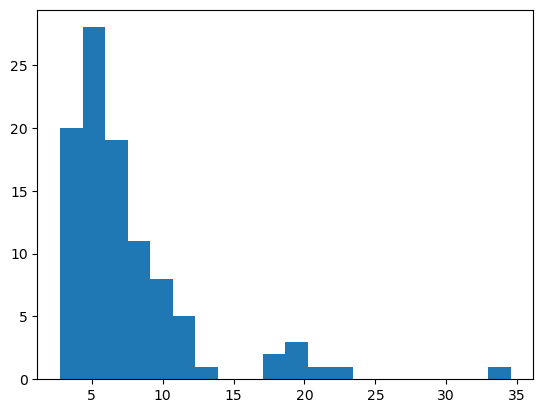

In [607]:
plt.hist(samples['sigma_beta'], bins='auto')

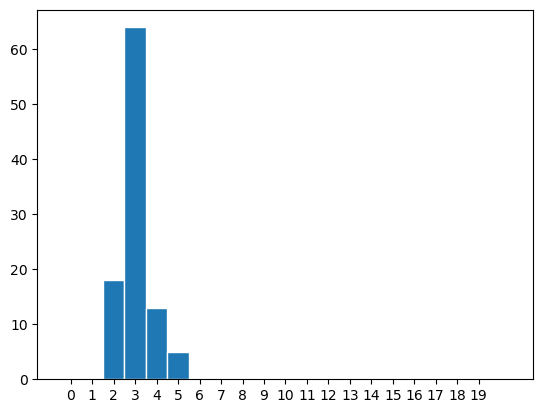

In [608]:
plt.hist(np.sum(samples['zs'], axis=(1))[-100:], bins=np.linspace(-0.5, 20.5, num=22), edgecolor='w')
plt.xticks(np.arange(0, 20))
plt.show()

{'amplitudes': array([9.92017132, 6.28843888, 8.5552384 ]), 'frequencies': array([2.49797582, 3.47441551, 2.6387138 ]), 'phases': array([4.48564543, 4.11236189, 2.70714569])}


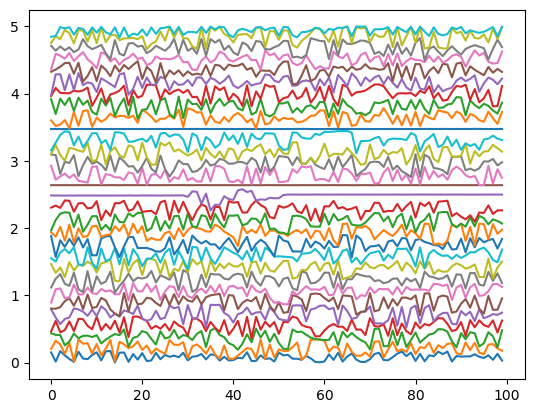

In [609]:
plt.plot(samples['freqs'])
print(inj_params)

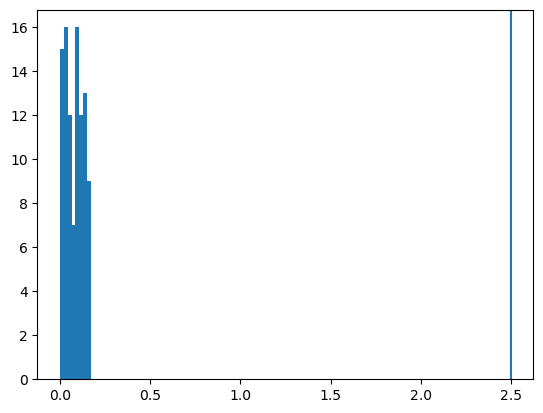

In [610]:
plt.hist(samples['freqs'][:, 0], bins='auto')
ax = plt.gca()
ax.axvline(inj_params['frequencies'][0])
plt.show()

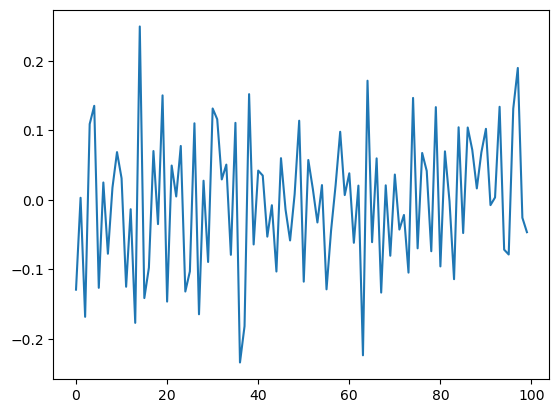

In [611]:
plt.plot(samples['beta'][:, 1])

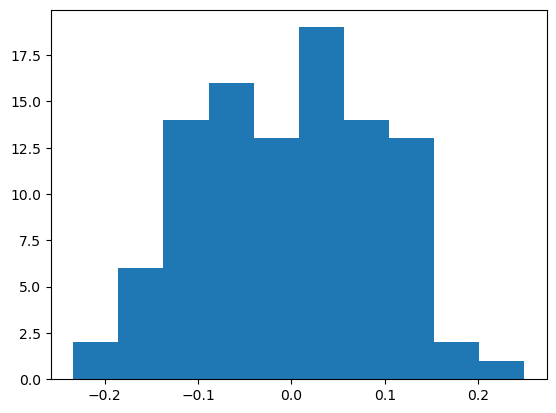

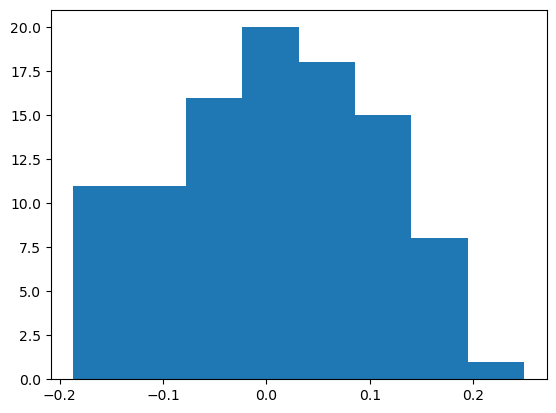

In [612]:
plt.hist(samples['beta'][:, 1])
plt.show()
plt.hist(samples['beta'][:, 7], bins='auto')
plt.show()